In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
'''图片数据集载入'''
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
transform1 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform2 = transforms.Compose([
    transforms.Resize([300, 300]),
    transforms.RandomCrop([128, 128]), #随机裁剪
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform3 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomAffine(20),  #随机仿射变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform4 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomEqualize(0.9),  #概率直方图均衡
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform5 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomHorizontalFlip(p=1),  #水平翻转
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform6 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(brightness=(0.5, 2)),  #亮度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform7 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(contrast=(0.5, 2)),  #对比度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform8 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(saturation=(0.5, 2)),  #饱和度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
train_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_evaluated_splited/train/downdog'
test_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_evaluated_splited/test/downdog'
data1 = torchvision.datasets.ImageFolder(root=train_path,transform=transform1) 
data2 = torchvision.datasets.ImageFolder(root=train_path,transform=transform2)
data3 = torchvision.datasets.ImageFolder(root=train_path,transform=transform3)
data4 = torchvision.datasets.ImageFolder(root=train_path,transform=transform4)
data5 = torchvision.datasets.ImageFolder(root=train_path,transform=transform5)
data6 = torchvision.datasets.ImageFolder(root=train_path,transform=transform6)
data7 = torchvision.datasets.ImageFolder(root=train_path,transform=transform7)
data8 = torchvision.datasets.ImageFolder(root=train_path,transform=transform8)
trainset1 = data1+data2+data3+data4+data5+data6+data7+data8
testset1 = torchvision.datasets.ImageFolder(root=test_path,transform=transform1) 

In [4]:
'''骨架坐标点数据集载入'''
import torch
import pandas as pd
import numpy as np
df = pd.read_excel("/content/drive/MyDrive/yoga/landmarks/downdog_train_landmarks.xlsx")
#df = df[df['体式']=='downdog']
df.loc[df['标准/不标准']=='nonstandard', '是否标准编号'] = 0
df.loc[df['标准/不标准']=='standard', '是否标准编号'] = 1
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
#print(df)
dataset_train = df.values
dataset_train = np.array(dataset_train)
X_train = dataset_train[:,:-1].astype(float)
Y_train = dataset_train[:,-1:].astype(int).squeeze(-1)
X_train, Y_train = torch.Tensor(X_train),torch.LongTensor(Y_train) 
#print(X_train, Y_train)
df = pd.read_excel("/content/drive/MyDrive/yoga/landmarks/downdog_test_landmarks.xlsx")
#df = df[df['体式']=='downdog']
df.loc[df['标准/不标准']=='nonstandard', '是否标准编号'] = 0
df.loc[df['标准/不标准']=='standard', '是否标准编号'] = 1
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
dataset_test = df.values
dataset_test = np.array(dataset_test)
X_test = dataset_test[:,:-1].astype(float)
Y_test = dataset_test[:,-1:].astype(int).squeeze(-1)
X_test, Y_test = torch.Tensor(X_test),torch.LongTensor(Y_test)
#print(X_test, Y_test)
trainset2_data =  torch.utils.data.TensorDataset(X_train,Y_train)
trainset2 = trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data
testset2 = torch.utils.data.TensorDataset(X_test,Y_test)


In [5]:
'''训练集合并'''
import numpy as np
import torch.utils.data as data
list_x_train = []
list_y_train = []
for i in range(len(trainset1)):
  set1 = torch.flatten(trainset1[i][0])
  set = torch.cat([set1, trainset2[i][0]],0)
  list_x_train.append(set)
  list_y_train.append(trainset1[i][1])
x_train = np.array(list_x_train)
y_train = np.array(list_y_train)
print(x_train)
print(y_train)
class Mydataset(data.Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.idx = list()
        for item in x:
            self.idx.append(item)
        pass
    def __getitem__(self, index):
        input_data = self.idx[index] #可继续进行数据增强，这里没有进行数据增强操作
        target = self.y[index]
        return input_data, target
    def __len__(self):
        return len(self.idx)
trainset = Mydataset(x_train,y_train)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True)

/usr/local/lib/python3.8/dist-packages/PIL/Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


KeyboardInterrupt: ignored

In [ ]:
torch.save(trainset,"/content/drive/MyDrive/yoga/datasets/eva_downdog2_trainset.pt" )

In [ ]:
'''测试集合并'''
import numpy as np
import torch.utils.data as data
list_x_test = []
list_y_test = []
for i in range(len(testset1)):
  set1 = torch.flatten(testset1[i][0])
  set = torch.cat([set1, testset2[i][0]],0)
  list_x_test.append(set)
  list_y_test.append(testset1[i][1])
x_test = np.array(list_x_test)
y_test = np.array(list_y_test)
testset = Mydataset(x_test,y_test)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=4, shuffle=False)

In [ ]:
torch.save(testset,"/content/drive/MyDrive/yoga/datasets/eva_downdog2_testset.pt" )

In [6]:
import torch.utils.data as data
class Mydataset(data.Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.idx = list()
        for item in x:
            self.idx.append(item)
        pass
    def __getitem__(self, index):
        input_data = self.idx[index] #可继续进行数据增强，这里没有进行数据增强操作
        target = self.y[index]
        return input_data, target
    def __len__(self):
        return len(self.idx)
trainset = torch.load("/content/drive/MyDrive/yoga/datasets/eva_downdog2_trainset.pt")
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True)

In [7]:
testset = torch.load("/content/drive/MyDrive/yoga/datasets/eva_downdog2_testset.pt")
testloader = torch.utils.data.DataLoader(
    testset, batch_size=4, shuffle=False)

In [8]:
'''MLP网络'''
import torch.nn as nn
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.all = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Dropout(p=0.5),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        out = self.all(x)
        return out

In [15]:
'''VGG19与MLP网络全连接层拼接网络'''
import torch.nn as nn
import torchvision.models as models
vgg19 = models.vgg19(pretrained=True)
vgg19.classifier = nn.Sequential(*list(vgg19.classifier.children())[:-1])  
mlp_pre = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog_contrast2.pkl')
mlp_pre.all =nn.Sequential(*list(mlp_pre.all.children())[:-1])
class fusionnet(nn.Module):
    def __init__(self, num_class=2):
        super().__init__()
        self.vgg = vgg19
        self.mlp = mlp_pre
        self.fc_out = nn.Linear(67 + 4096, num_class)
    def forward(self, x):
        #print(x.size())
        x1 = x[..., :128*128*3]
        x1 = torch.reshape(x1, (-1,3,128,128))
        #print(x1.shape)
        x2 = x[..., 128*128*3:]
        #print(x2.shape)
        x1 = self.vgg(x1)
        x2 = self.mlp(x2)
        #print(x1.shape)
        #print(x2.shape)
        out = torch.concat([x1,x2], 1)
        output = self.fc_out(out)
        return output

In [21]:
'''定义训练和测试函数'''
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
def train_test(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    train_loss_list = []
    test_loss_list = []
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images, labels = data
              images, labels = images.to(device), labels.to(device)
              outputs = net(images)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog2.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/trainloss2.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/testloss2.csv',index=False)
import pandas as pd
def test(net):
    correct = 0
    total = 0
    total_l = [0,0]
    correct_l = [0,0]
    pred_y = torch.tensor([]).to(device)
    Y_test = torch.tensor([]).to(device)
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            Y_test = torch.cat([Y_test,labels])
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(2):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    print('测试集精度为：%d%%'%(100 * correct / total))
    print('测试集中不标准动作图片的预测精度为：%d%%'%(100 * correct_l[0] / total_l[0]))
    print('测试集中标准动作图片的预测精度为：%d%%'%(100 * correct_l[1] / total_l[1]))
    print('混淆矩阵为：')
    print(pd.crosstab(Y_test.cpu(), pred_y.cpu()))

In [22]:
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
import pandas as pd
def train_test2(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    df_trainloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/downdog/trainloss2.csv')
    train_loss_list = df_trainloss['trainloss'].tolist()
    df_testloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/downdog/testloss2.csv')
    test_loss_list = df_testloss['testloss'].tolist()
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs1, labels = data
            inputs1, labels = inputs1.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs1)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images1, labels = data
              images1, labels = images1.to(device), labels.to(device)
              outputs = net(images1)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog2.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/trainloss2.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/testloss2.csv',index=False)

In [23]:
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
test(fusionnet().to(device))

测试集精度为：40%
测试集中不标准动作图片的预测精度为：53%
测试集中标准动作图片的预测精度为：30%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     17   15
1.0     28   12


[1,  100] loss:3.488
[1,  200] loss:3.069
[1,  300] loss:2.612
Test set: Average loss: 1.0123
[2,  100] loss:2.287
[2,  200] loss:2.392
[2,  300] loss:2.151
Test set: Average loss: 0.7686
[3,  100] loss:1.847
[3,  200] loss:1.964
[3,  300] loss:2.051
Test set: Average loss: 0.6794
[4,  100] loss:1.624
[4,  200] loss:1.809
[4,  300] loss:1.765
Test set: Average loss: 0.6599
[5,  100] loss:1.566
[5,  200] loss:1.562
[5,  300] loss:1.603
Test set: Average loss: 0.7951
[6,  100] loss:1.689
[6,  200] loss:1.496
[6,  300] loss:1.444
Test set: Average loss: 0.7570
[7,  100] loss:1.417
[7,  200] loss:1.483
[7,  300] loss:1.344
Test set: Average loss: 0.8442
[8,  100] loss:1.362
[8,  200] loss:1.412
[8,  300] loss:1.306
Test set: Average loss: 0.8990
[9,  100] loss:1.292
[9,  200] loss:1.379
[9,  300] loss:1.168
Test set: Average loss: 0.7427
[10,  100] loss:1.219
[10,  200] loss:1.193
[10,  300] loss:1.081
Test set: Average loss: 0.7771
[11,  100] loss:1.216
[11,  200] loss:1.239
[11,  300] lo

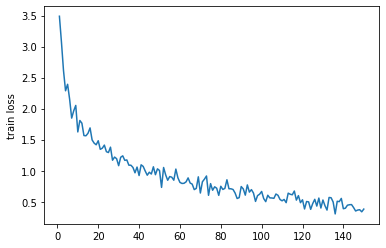

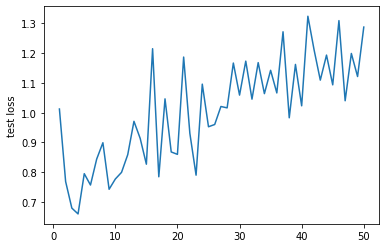

Finished Training


In [25]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKyING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
train_test(fusionnet().to(device),50,100)

[1,  100] loss:0.476
[1,  200] loss:0.364
[1,  300] loss:0.350
Test set: Average loss: 1.0238
[2,  100] loss:0.367
[2,  200] loss:0.396
[2,  300] loss:0.405
Test set: Average loss: 1.0856
[3,  100] loss:0.442
[3,  200] loss:0.547
[3,  300] loss:0.371
Test set: Average loss: 1.1303
[4,  100] loss:0.441
[4,  200] loss:0.384
[4,  300] loss:0.399
Test set: Average loss: 1.2978
[5,  100] loss:0.381
[5,  200] loss:0.296
[5,  300] loss:0.423
Test set: Average loss: 1.5238
[6,  100] loss:0.314
[6,  200] loss:0.417
[6,  300] loss:0.440
Test set: Average loss: 1.2299
[7,  100] loss:0.392
[7,  200] loss:0.341
[7,  300] loss:0.393
Test set: Average loss: 1.2612
[8,  100] loss:0.315
[8,  200] loss:0.281
[8,  300] loss:0.407
Test set: Average loss: 1.3192
[9,  100] loss:0.293
[9,  200] loss:0.281
[9,  300] loss:0.301
Test set: Average loss: 1.0971
[10,  100] loss:0.284
[10,  200] loss:0.387
[10,  300] loss:0.357
Test set: Average loss: 1.3526
[11,  100] loss:0.275
[11,  200] loss:0.302
[11,  300] lo

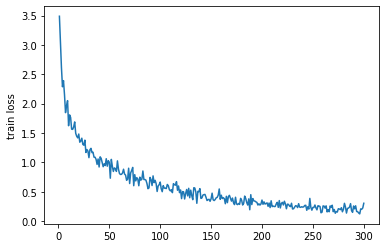

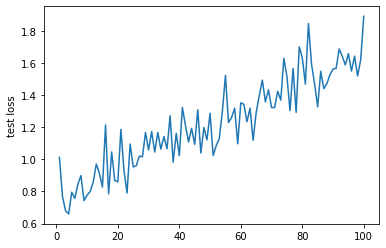

Finished Training


In [29]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog2.pkl')
train_test2(model.to(device),50,100)

[1,  100] loss:0.163
[1,  200] loss:0.156
[1,  300] loss:0.186
Test set: Average loss: 1.5500
[2,  100] loss:0.141
[2,  200] loss:0.169
[2,  300] loss:0.128
Test set: Average loss: 1.3261
[3,  100] loss:0.119
[3,  200] loss:0.160
[3,  300] loss:0.168
Test set: Average loss: 1.5215
[4,  100] loss:0.140
[4,  200] loss:0.175
[4,  300] loss:0.136
Test set: Average loss: 1.9115
[5,  100] loss:0.189
[5,  200] loss:0.129
[5,  300] loss:0.128
Test set: Average loss: 1.5770
[6,  100] loss:0.118
[6,  200] loss:0.159
[6,  300] loss:0.135
Test set: Average loss: 1.7591
[7,  100] loss:0.167
[7,  200] loss:0.192
[7,  300] loss:0.166
Test set: Average loss: 1.7180
[8,  100] loss:0.208
[8,  200] loss:0.145
[8,  300] loss:0.172
Test set: Average loss: 1.4139
[9,  100] loss:0.108
[9,  200] loss:0.156
[9,  300] loss:0.190
Test set: Average loss: 1.3942
[10,  100] loss:0.172
[10,  200] loss:0.196
[10,  300] loss:0.150
Test set: Average loss: 1.6024
[11,  100] loss:0.124
[11,  200] loss:0.153
[11,  300] lo

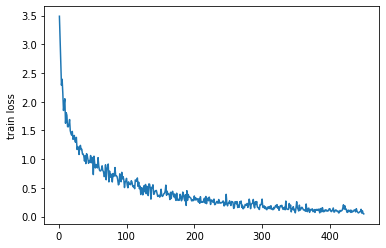

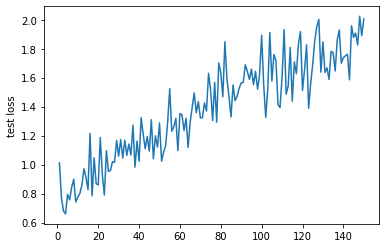

Finished Training


In [36]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog2.pkl')
train_test2(model.to(device),50,100)

In [41]:
#训练150个epoch的测试精度
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog2.pkl')
model.to(device)
print("测试精度如下：")
test(model)

测试精度如下：
测试集精度为：70%
测试集中不标准动作图片的预测精度为：62%
测试集中标准动作图片的预测精度为：77%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     20   12
1.0      9   31
